In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
BASE = Path(r"C:\Users\saura\KDDCup2015_research")

RAW = BASE / "data" / "raw" / "kddcup2015"

TRAIN = RAW / "train"
TEST = RAW / "test"

print("RAW DATA:")
print(RAW)

print("\nTRAIN:")
print(TRAIN)

print("\nTEST:")
print(TEST)

RAW DATA:
C:\Users\saura\KDDCup2015_research\data\raw\kddcup2015

TRAIN:
C:\Users\saura\KDDCup2015_research\data\raw\kddcup2015\train

TEST:
C:\Users\saura\KDDCup2015_research\data\raw\kddcup2015\test


In [3]:
files = {
    "date": RAW / "date.csv",
    "object": RAW / "object.csv",

    "enrollment_train": TRAIN / "enrollment_train.csv",
    "log_train": TRAIN / "log_train.csv",
    "truth_train": TRAIN / "truth_train.csv",

    "enrollment_test": TEST / "enrollment_test.csv",
    "log_test": TEST / "log_test.csv",
    "truth_test": TEST / "truth_test.csv"
}

for name, path in files.items():
    if path.exists():
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"✅ {name:22} {size_mb:10.2f} MB")
    else:
        print(f"❌ {name:22} MISSING")

✅ date                         0.00 MB
✅ object                       2.99 MB
✅ enrollment_train             8.44 MB
✅ log_train                  589.63 MB
✅ truth_train                  0.97 MB
✅ enrollment_test              5.63 MB
✅ log_test                   389.51 MB
✅ truth_test                   0.65 MB


In [7]:
date_df = pd.read_csv(files["date"])
object_df = pd.read_csv(files["object"])

enrollment_train = pd.read_csv(files["enrollment_train"])
truth_train = pd.read_csv(files["truth_train"])

enrollment_test = pd.read_csv(files["enrollment_test"])
truth_test = pd.read_csv(files["truth_test"])

print("Small files loaded successfully.")

Small files loaded successfully.


In [8]:
print("=== ENROLLMENT TRAIN ===")
print(enrollment_train.shape)
print(enrollment_train.columns.tolist())

print("\n=== TRUTH TRAIN ===")
print(truth_train.shape)
print(truth_train.columns.tolist())

print("\n=== ENROLLMENT TEST ===")
print(enrollment_test.shape)
print(enrollment_test.columns.tolist())

print("\n=== TRUTH TEST ===")
print(truth_test.shape)
print(truth_test.columns.tolist())

print("\n=== OBJECT ===")
print(object_df.shape)
print(object_df.columns.tolist())

print("\n=== DATE ===")
print(date_df.shape)
print(date_df.columns.tolist())

=== ENROLLMENT TRAIN ===
(120542, 3)
['enrollment_id', 'username', 'course_id']

=== TRUTH TRAIN ===
(120541, 2)
['1', '0']

=== ENROLLMENT TEST ===
(80362, 3)
['enrollment_id', 'username', 'course_id']

=== TRUTH TEST ===
(80361, 2)
['2', '0']

=== OBJECT ===
(27249, 5)
['course_id', 'module_id', 'category', 'children', 'start']

=== DATE ===
(39, 3)
['course_id', 'from', 'to']


In [9]:
truth_train = pd.read_csv(
    files["truth_train"],
    header=None,
    names=["enrollment_id", "dropout"]
)

truth_test = pd.read_csv(
    files["truth_test"],
    header=None,
    names=["enrollment_id", "dropout"]
)

print("TRUTH TRAIN:")
print(truth_train.shape)
display(truth_train.head())

print("\nTRUTH TEST:")
print(truth_test.shape)
display(truth_test.head())

TRUTH TRAIN:
(120542, 2)


,enrollment_id,dropout
0,1,0
1,3,0
2,4,0
3,5,0
4,6,0



TRUTH TEST:
(80362, 2)


,enrollment_id,dropout
0,2,0
1,8,0
2,10,1
3,11,0
4,15,0


In [10]:
print("=== TRAIN LABEL CHECK ===")

print("Enrollment records:", len(enrollment_train))
print("Truth records:", len(truth_train))

print(
    "Duplicate enrollment IDs in enrollment_train:",
    enrollment_train["enrollment_id"].duplicated().sum()
)

print(
    "Duplicate enrollment IDs in truth_train:",
    truth_train["enrollment_id"].duplicated().sum()
)

print(
    "Missing dropout values:",
    truth_train["dropout"].isna().sum()
)

print("\nDropout distribution:")
print(truth_train["dropout"].value_counts())

print("\nDropout percentage:")
print(
    truth_train["dropout"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

=== TRAIN LABEL CHECK ===
Enrollment records: 120542
Truth records: 120542
Duplicate enrollment IDs in enrollment_train: 0
Duplicate enrollment IDs in truth_train: 0
Missing dropout values: 0

Dropout distribution:
dropout
1    95581
0    24961
Name: count, dtype: int64

Dropout percentage:
dropout
1    79.29
0    20.71
Name: proportion, dtype: float64


In [11]:
labelled_train = enrollment_train.merge(
    truth_train,
    on="enrollment_id",
    how="inner",
    validate="one_to_one"
)

print("Labelled training dataset shape:")
print(labelled_train.shape)

print("\nColumns:")
print(labelled_train.columns.tolist())

print("\nFirst 5 rows:")
display(labelled_train.head())

Labelled training dataset shape:
(120542, 4)

Columns:
['enrollment_id', 'username', 'course_id', 'dropout']

First 5 rows:


,enrollment_id,username,course_id,dropout
0,1,9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,0
1,3,1qXC7Fjbwp66GPQc6pHLfEuO8WKozxG4,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,0
2,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,0
3,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,0
4,6,dpK33RH9yepUAnyoywRwBt1AJzxGlaja,AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,0


In [12]:
PROCESSED = BASE / "data" / "processed"

PROCESSED.mkdir(parents=True, exist_ok=True)

labelled_path = PROCESSED / "kddcup2015_train_labelled.csv"

labelled_train.to_csv(
    labelled_path,
    index=False
)

print("Saved successfully:")
print(labelled_path)

Saved successfully:
C:\Users\saura\KDDCup2015_research\data\processed\kddcup2015_train_labelled.csv


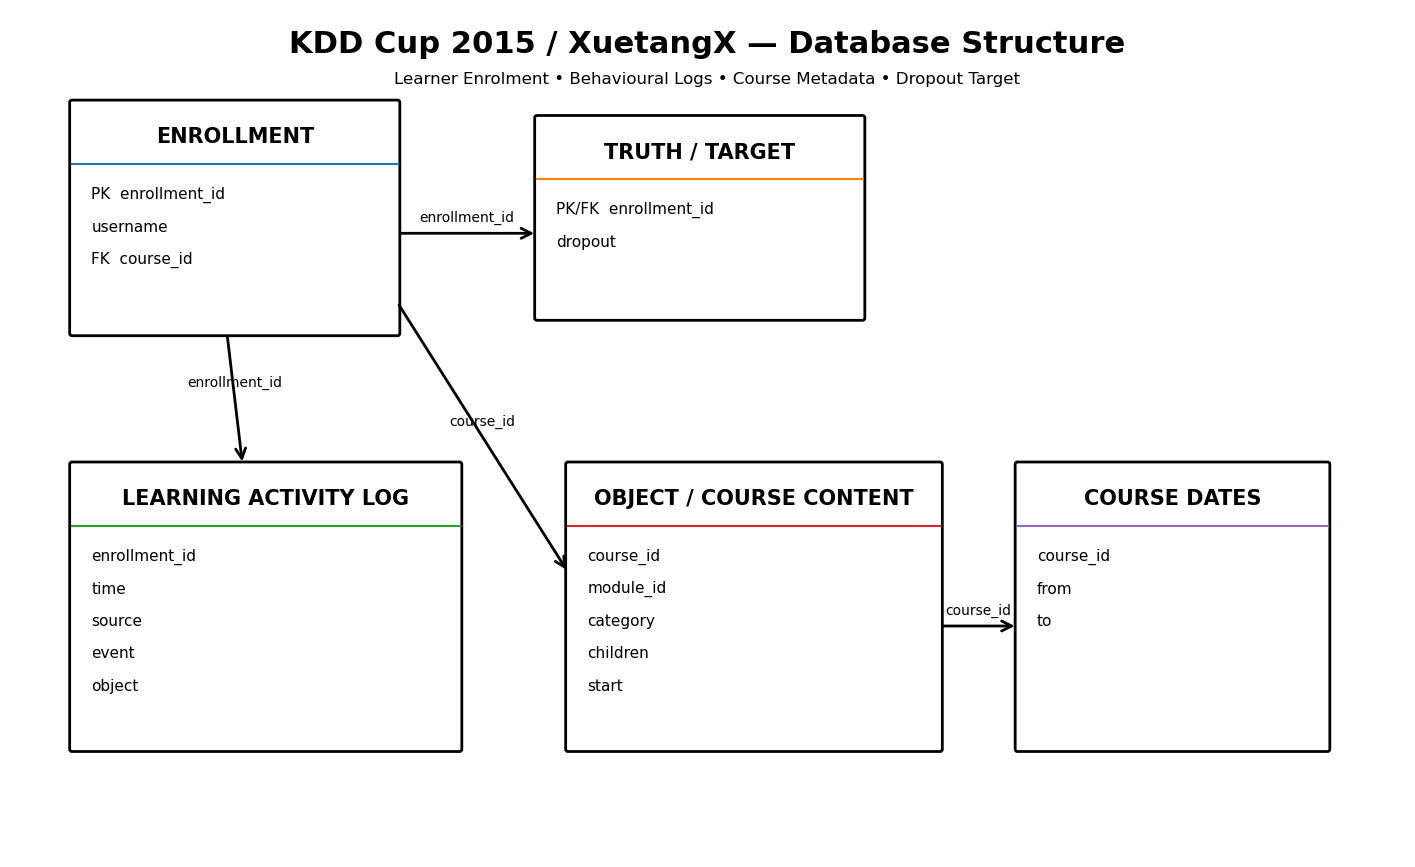

Saved to:
C:\Users\saura\KDDCup2015_research\results\KDDCup2015_database_structure.png


In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 11))

ax.set_xlim(0, 18)
ax.set_ylim(0, 11)
ax.axis("off")

def draw_table(x, y, width, height, title, fields):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03",
        linewidth=2,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)

    # Table title
    ax.text(
        x + width / 2,
        y + height - 0.45,
        title,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold"
    )

    # Divider
    ax.plot(
        [x, x + width],
        [y + height - 0.8, y + height - 0.8],
        linewidth=1.5
    )

    # Fields
    start_y = y + height - 1.2

    for i, field in enumerate(fields):
        ax.text(
            x + 0.25,
            start_y - i * 0.42,
            field,
            ha="left",
            va="center",
            fontsize=11
        )


def arrow(x1, y1, x2, y2, label=None):
    arr = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=18,
        linewidth=2
    )
    ax.add_patch(arr)

    if label:
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + 0.15,
            label,
            ha="center",
            fontsize=10
        )


# ---------------------------------------------------------
# TABLES
# ---------------------------------------------------------

# Enrollment
draw_table(
    0.8, 6.8, 4.2, 3.0,
    "ENROLLMENT",
    [
        "PK  enrollment_id",
        "username",
        "FK  course_id"
    ]
)

# Truth / Target
draw_table(
    6.8, 7.0, 4.2, 2.6,
    "TRUTH / TARGET",
    [
        "PK/FK  enrollment_id",
        "dropout"
    ]
)

# Log
draw_table(
    0.8, 1.4, 5.0, 3.7,
    "LEARNING ACTIVITY LOG",
    [
        "enrollment_id",
        "time",
        "source",
        "event",
        "object"
    ]
)

# Object
draw_table(
    7.2, 1.4, 4.8, 3.7,
    "OBJECT / COURSE CONTENT",
    [
        "course_id",
        "module_id",
        "category",
        "children",
        "start"
    ]
)

# Date
draw_table(
    13.0, 1.4, 4.0, 3.7,
    "COURSE DATES",
    [
        "course_id",
        "from",
        "to"
    ]
)


# ---------------------------------------------------------
# RELATIONSHIPS
# ---------------------------------------------------------

# Enrollment -> Truth
arrow(
    5.0, 8.1,
    6.8, 8.1,
    "enrollment_id"
)

# Enrollment -> Log
arrow(
    2.8, 6.8,
    3.0, 5.1,
    "enrollment_id"
)

# Enrollment -> Object
arrow(
    5.0, 7.2,
    7.2, 3.7,
    "course_id"
)

# Object -> Date
arrow(
    12.0, 3.0,
    13.0, 3.0,
    "course_id"
)


# ---------------------------------------------------------
# TITLE
# ---------------------------------------------------------

ax.text(
    9,
    10.55,
    "KDD Cup 2015 / XuetangX — Database Structure",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)

ax.text(
    9,
    10.1,
    "Learner Enrolment • Behavioural Logs • Course Metadata • Dropout Target",
    ha="center",
    va="center",
    fontsize=12
)


# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

output_file = BASE / "results" / "KDDCup2015_database_structure.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(output_file)